# Notebook for Master's Thesis

_Jonatan Haraldsson_ [jonhara@chalmers.se](mailto:jonhara@chalmers.se)

_Jesper Noord_ [noord@chalmers.se](mailto:noord@chalmers.se)



In [6]:
# relevant modules for this notebook
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
import emcee
import corner
import scipy
from scipy.stats import gamma, invgamma, t, norm, norminvgauss, mode, uniform
import seaborn as sns
import random
import sklearn
import scipy.constants as const
import random
import tqdm
from tqdm import trange
import keras as keras
import tensorflow as tf

# import  settings
import plot_settings
plot_settings.apply()

np.random.seed(123)

In [31]:
import pybamm


model = pybamm.lithium_ion.SPM()

geometry = model.default_geometry



param = model.default_parameter_values

def my_current(t):
    return pybamm.sin(20 *np.pi* t / (3600)) + 1  # Example: sinusoidal current

param["Current function [A]"] = my_current


param.process_model(model)
param.process_geometry(geometry)

mesh = pybamm.Mesh(geometry, model.default_submesh_types, model.default_var_pts)

disc = pybamm.Discretisation(mesh, model.default_spatial_methods)
disc.process_model(model)


In [32]:
# # for var in model.variables:
# #     print(var)
# for param,paramvals in zip(model.default_parameter_values.keys(),model.default_parameter_values.values()):
#     print(f'{param} \t\t {paramvals}')

model.print_parameter_info()

┌───────────────────────────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Parameter                                                 │ Type of parameter                                                                                                                                                                                           │
├───────────────────────────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ Separator thickness [m]                                   │ Parameter                                                                                                                             

In [33]:
# for v,V in zip(model.variables.keys(), model.variables.values()):
#     print(f"\t- {v}\t\t{V}")

In [34]:
solver = model.default_solver
s = 10 * 3600


t_eval = np.linspace(0, s, 100)

solution = solver.solve(model, t_eval)



In [35]:
N = []
variable_names = []
for vals in model.variables.keys():
    variable_names.append(str(vals))
    N.append(len(solution[vals].entries))
    print(f'{solution[vals].entries.shape} \t {vals}')

(230,) 	 Time [s]
(230,) 	 Time [min]
(230,) 	 Time [h]
(60, 230) 	 x [m]
(20, 230) 	 x_n [m]
(20, 230) 	 x_s [m]
(20, 230) 	 x_p [m]
(20, 20, 230) 	 r_n [m]
(20, 20, 230) 	 r_p [m]
(230,) 	 Current variable [A]
(230,) 	 Total current density [A.m-2]
(230,) 	 Current [A]
(230,) 	 C-rate
(230,) 	 Discharge capacity [A.h]
(230,) 	 Throughput capacity [A.h]
(230,) 	 Discharge energy [W.h]
(230,) 	 Throughput energy [W.h]
(60, 230) 	 Porosity
(20, 230) 	 Negative electrode porosity
(230,) 	 X-averaged negative electrode porosity
(20, 230) 	 Separator porosity
(230,) 	 X-averaged separator porosity
(20, 230) 	 Positive electrode porosity
(230,) 	 X-averaged positive electrode porosity
(60, 230) 	 Porosity change
(20, 230) 	 Negative electrode porosity change [s-1]
(230,) 	 X-averaged negative electrode porosity change [s-1]
(20, 230) 	 Separator porosity change [s-1]
(230,) 	 X-averaged separator porosity change [s-1]
(20, 230) 	 Positive electrode porosity change [s-1]
(230,) 	 X-averaged 

Text(0.5, 0, 'Time [s]')

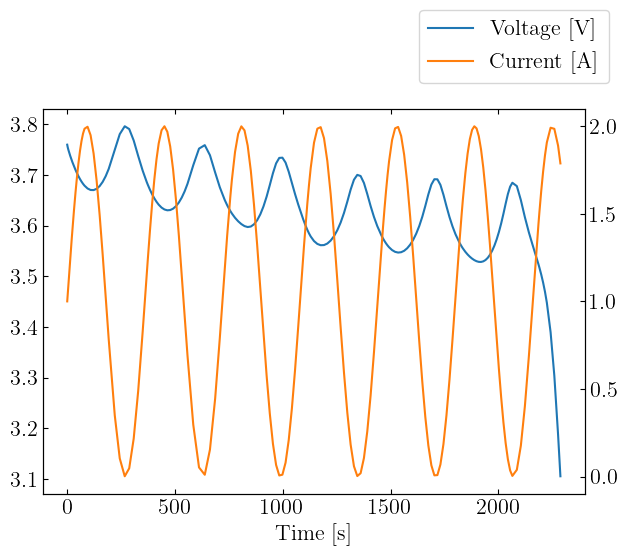

In [41]:
plot2 = 'Current [A]'

T = solution["Time [s]"].entries
c = solution[plot2].entries
V = solution["Voltage [V]"].entries

f,ax = plt.subplots(1,1,figsize=(7,5))
ax1 =ax.twinx()
ax.plot(T,V,color = 'tab:blue',label = 'Voltage [V]')
ax1.plot(T,c,color = 'tab:orange',label =f'{plot2}')
f.legend(bbox_to_anchor=(0.95,1.1))    
ax.set_xlabel('Time [s]')

In [37]:
solution.save_data('output_solution.npz')

In [38]:
data = np.load('output_solution.npz',allow_pickle=True)
for key in data:
    print(f'{key} \t {data[key].shape}')

Time [s] 	 (230,)
Time [min] 	 (230,)
Time [h] 	 (230,)
x [m] 	 (60, 230)
x_n [m] 	 (20, 230)
x_s [m] 	 (20, 230)
x_p [m] 	 (20, 230)
r_n [m] 	 (20, 20, 230)
r_p [m] 	 (20, 20, 230)
Current variable [A] 	 (230,)
Total current density [A.m-2] 	 (230,)
Current [A] 	 (230,)
C-rate 	 (230,)
Discharge capacity [A.h] 	 (230,)
Throughput capacity [A.h] 	 (230,)
Discharge energy [W.h] 	 (230,)
Throughput energy [W.h] 	 (230,)
Porosity 	 (60, 230)
Negative electrode porosity 	 (20, 230)
X-averaged negative electrode porosity 	 (230,)
Separator porosity 	 (20, 230)
X-averaged separator porosity 	 (230,)
Positive electrode porosity 	 (20, 230)
X-averaged positive electrode porosity 	 (230,)
Porosity change 	 (60, 230)
Negative electrode porosity change [s-1] 	 (20, 230)
X-averaged negative electrode porosity change [s-1] 	 (230,)
Separator porosity change [s-1] 	 (20, 230)
X-averaged separator porosity change [s-1] 	 (230,)
Positive electrode porosity change [s-1] 	 (20, 230)
X-averaged positive 